In [1]:
from jax import jit, random, vmap
import numpy as np
from matplotlib.ticker import LinearLocator
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from configuration.rte2d_settings_ex7_aprfm import get_config
from constraints.continuous2d_2 import (
    MicroMacroPointwiseBoundaryConstraint2D as BC,
    MicroMacroPointwiseInteriorConstraint2D as EQ,
)
from geometry.meshxd_ds import UniformMeshXY, UniformMeshXYV
from modules.generator import SampleHole
from modules.solution import MicroMacroConstructor2D
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["rho/g"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_rho = UniformMeshXY(domain=domain, strides=strides)
mesh_g = UniformMeshXYV(domain=domain, strides=strides)

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_y, dummy_theta = jnp.split(
    jnp.array([0.5, 0.5, 0.0]), 3, axis=0
)
params = {}
eq_instance = rte.apply(params, dummy_x, dummy_y, dummy_theta)
bc_instance = bc.apply(params, dummy_x, dummy_y, dummy_theta)

In [6]:
eq_instance.shape, bc_instance.shape

((3, 576), (576,))

In [7]:
def eq_fn(x, y, theta):
    return partial(rte.apply, params)(x, y, theta)


def bc_fn(x, y, theta):
    return partial(bc.apply, params)(x, y, theta)


def rhs_fn(x, y, theta):
    q = source_fn(x, y, theta)
    quadratures = leggauss(num_quads, (0.0, 2.0 * jnp.pi))
    pts, ws = quadratures
    weighted_sum = vmap(source_fn, [None, None, 0])(x, y, pts).squeeze() @ ws
    avg_q = weighted_sum / jnp.pi / 2.0
    return jnp.array([avg_q.squeeze(), kn * (q - avg_q).squeeze(), 0.0])
    # return jnp.array([avg_q.squeeze(), kn * (q - avg_q).squeeze()])


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [8]:
sampler = SampleHole(
    domain=domain, collocation_sizes=collocation_sizes, mode=mode
)
pts_int = sampler.pts_int
pts_left, pts_right, pts_lower, pts_upper = (
    sampler.pts_left,
    sampler.pts_right,
    sampler.pts_lower,
    sampler.pts_upper,
)
pts_left_hole, pts_right_hole, pts_lower_hole, pts_upper_hole = (
    sampler.pts_left_hole,
    sampler.pts_right_hole,
    sampler.pts_lower_hole,
    sampler.pts_upper_hole,
)

In [9]:
# Evaluate the functions
bc_left, bc_right, bc_lower, bc_upper = (
    vmap_bc_fn(*pts_left),
    vmap_bc_fn(*pts_right),
    vmap_bc_fn(*pts_lower),
    vmap_bc_fn(*pts_upper),
)
bc_left_hole, bc_right_hole, bc_lower_hole, bc_upper_hole = (
    vmap_bc_fn(*pts_left_hole),
    vmap_bc_fn(*pts_right_hole),
    vmap_bc_fn(*pts_lower_hole),
    vmap_bc_fn(*pts_upper_hole),
)
print(
    f"bc_left.shape: {bc_left.shape}, bc_right_hole.shape: {bc_right_hole.shape}"
)

bc_left.shape: (8192, 576), bc_right_hole.shape: (8192, 576)


In [10]:
eq_int = vmap_eq_fn(*pts_int)
print(f"eq_int.shape: {eq_int.shape}")

eq_int.shape: (24000, 3, 576)


In [11]:
x_int, y_int, theta_int = pts_int
pts_int = x_int.squeeze(), y_int.squeeze(), theta_int.squeeze()
rhs_int = vmap_rhs_fn(*pts_int)
print(f"rhs_int.shape: {rhs_int.shape}")

rhs_int.shape: (24000, 3)


In [12]:
def ex_solution_2d(
    x: jnp.ndarray, y: jnp.ndarray, theta: jnp.ndarray
) -> jnp.ndarray:
    return x * y - kn * (x * jnp.sin(theta) + y * jnp.cos(theta))


vmap_ex_fn = vmap(jit(ex_solution_2d))


In [13]:
# Save the data
matrix_A = np.concatenate(
    [
        bc_left,
        bc_right,
        bc_lower,
        bc_upper,
        bc_left_hole,
        bc_right_hole,
        bc_lower_hole,
        bc_upper_hole,
        eq_int.reshape(-1, num_unknowns),
    ],
    axis=0,
)

vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size_x, bdy_size_y, bdy_size_theta = collocation_sizes["boundary"]
vector_b[: 2 * bdy_size_y * bdy_size_theta, 0] = vmap_ex_fn(
    *pts_left
).squeeze()
vector_b[
    2 * bdy_size_y * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta,
    0,
] = vmap_ex_fn(*pts_right).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta,
    0,
] = vmap_ex_fn(*pts_lower).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 2 * bdy_size_x * bdy_size_theta : 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta,
    0,
] = vmap_ex_fn(*pts_upper).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 4 * bdy_size_x * bdy_size_theta : 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 2 * bdy_size_y * bdy_size_theta,
    0,
] = vmap_ex_fn(*pts_left_hole).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 2 * bdy_size_y * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta,
    0,
] = vmap_ex_fn(*pts_right_hole).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta,
    0,
] = vmap_ex_fn(*pts_lower_hole).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta,
    0,
] = vmap_ex_fn(*pts_upper_hole).squeeze()

vector_b[
    4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta :,
    0,
] = rhs_int.reshape(-1)

print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (137536, 576), Vector b: (137536, 1)


In [14]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (576, 1)


In [15]:
from numpy.linalg import cond

print(f"Condition number: {cond(matrix_A):.4e}")


Condition number: 1.0707e+09


In [16]:
(
    np.abs(matrix_A @ vector_U - vector_b).max(),
    np.abs(matrix_A @ vector_U - vector_b).mean(),
)

(0.002619622928820231, 6.0956937712187633e-05)

In [17]:
# data = np.load("../src/data/weights.npz")
# vector_U = data["coefficients"]

In [18]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns,
)
constructor = MicroMacroConstructor2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [19]:
def approx_fn(x, y, theta):
    return partial(constructor.apply, params)(x, y, theta)

In [20]:
def rho(x, y):
    return x * y

In [21]:
def aver_fn(x, y):
    quadratures = leggauss(num_quads, (0.0, 2.0 * jnp.pi))
    pts, ws = quadratures
    weighted_sum = vmap(approx_fn, [None, None, 0])(x, y, pts) @ ws
    return weighted_sum / jnp.pi / 2.0

In [22]:
# vmap_approx_fn = vmap(approx_fn)
approx_fn = jit(approx_fn)

In [23]:
dummy_z = jnp.array([1.0, 0.0, 0.0])
dummy_x, dummy_y, dummy_v = jnp.split(dummy_z, 3, axis=-1)
print(f"f({dummy_z}) = {approx_fn(dummy_x, dummy_y, dummy_v)}")

f([1. 0. 0.]) = -131.93342072717093


In [24]:
mesh_x, mesh_y = np.linspace(-1.0, 1.0, 129), np.linspace(-1.0, 1.0, 129)

X, Y = np.meshgrid(mesh_x, mesh_y)
rho_approx = vmap(aver_fn, [0, 0])(X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(
    X.shape
)
rho_ex = vmap(rho, [0, 0])(X, Y)

In [25]:
shape_matrix = np.ones(rho_ex.shape)
shape_matrix[
    len(mesh_x) // 3 : len(mesh_x) // 3 * 2,
    len(mesh_y) // 3 : len(mesh_y) // 3 * 2,
] = None
F, F_hat = rho_ex * shape_matrix, rho_approx * shape_matrix

In [26]:
# np.savez(
#     f"../src/data/aprfm2d_ex6_solutions_{kn:.1e}.npz",
#     X=X,
#     Y=Y,
#     rho_hat=rho_approx * shape_matrix,
#     rho_ex=rho_ex * shape_matrix,
# )

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


FileNotFoundError: [Errno 2] No such file or directory: './figures/aprfm2d_1.0e+00_contourf_ex6_sin.png'

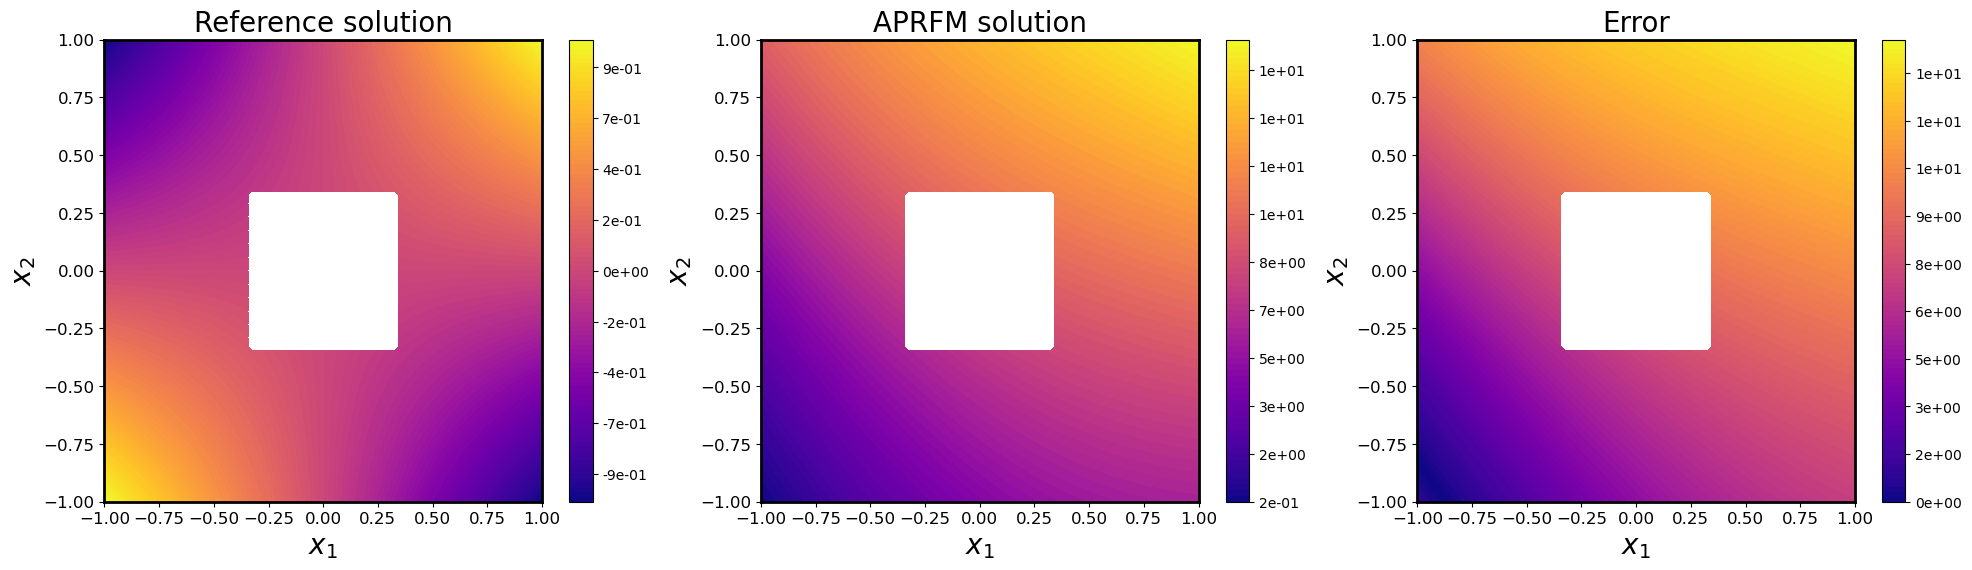

In [27]:
font_format = {"family": "Times New Roman", "size": 20}

plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
plt.contourf(X, Y, F, 100, cmap="plasma")
# font size and type
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

ax2 = plt.subplot(1, 3, 2)
plt.contourf(X, Y, F_hat, 100, cmap="plasma")
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("APRFM solution", font_format)
# # line width of four axises
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)

ax3 = plt.subplot(1, 3, 3)
plt.contourf(X, Y, np.abs(F - F_hat), 100, cmap="plasma")
# plt.contourf(X, V, np.abs(F - F_hat), 100, cmap='Spectral_r')
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("Error", font_format)
# # line width of four axises
ax3.spines["bottom"].set_linewidth(2)
ax3.spines["left"].set_linewidth(2)
ax3.spines["right"].set_linewidth(2)
ax3.spines["top"].set_linewidth(2)

plt.savefig(f"./figures/aprfm2d_{kn:.1e}_contourf_ex6_sin.png", dpi=300)
plt.show()
plt.close()

In [ ]:
shape_matrix = np.ones(rho_ex.shape)
shape_matrix[
    len(mesh_x) // 3 : len(mesh_x) // 3 * 2,
    len(mesh_y) // 3 : len(mesh_y) // 3 * 2,
] = 0.0
F, F_hat = rho_ex * shape_matrix, rho_approx * shape_matrix

jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F), kn

(Array(4871985.52509493, dtype=float64), 1.0)